In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.transforms as T

import numpy as np
import itertools

In [21]:
def select_device():
    return 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')

device = select_device()
device = select_device()

In [22]:
data_folder = './data/FMNIST' # This can be any directory you want
# to download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

In [23]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

class FMNISTDataset(Dataset):
    def __init__(self, x, y, transform=None, device="mps"):
        self.x = x
        self.y = y
        self.transform = transform
        self.device = device

    def __getitem__(self, ix):
        img = self.x[ix].float() / 255.0
        img = img.unsqueeze(0)

        if self.transform is not None:
            img = self.transform(img)

        x = img.view(-1)
        y = self.y[ix]

        return x.to(self.device), y.to(self.device)

    def __len__(self):
        return len(self.x)

def get_data(batch_size, transform=None, shuffle=True, device="mps"):
    train = FMNISTDataset(tr_images, tr_targets, transform=transform, device=device)
    ds = torch.utils.data.Subset(train, list(range(10_000))) # for faster training
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [24]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    # call your model like any python function on your batch of inputs
    prediction = model(x)
    # compute loss
    batch_loss = loss_fn(prediction, y)
    # based on the forward pass in `model(x)` compute all the gradients of
    # 'model.parameters()'
    batch_loss.backward()
    # apply new-weights = f(old-weights, old-weight-gradients)
    # where "f" is the optimizer
    opt.step()
    # Flush memory for next batch of calculations
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    # since there's no need for updating weights, we might
    # as well not compute the gradients
    with torch.no_grad():
        # get the prediction matrix for a tensor of `x` images
        prediction = model(x)
    # compute if the location of maximum in each row coincides
    # with ground truth
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()


In [25]:
@torch.no_grad()
def accuracy_loader(model, dl, max_batches=None):
    """
    Fast accuracy over a DataLoader.
    - uses no_grad + argmax + running counters
    - max_batches: if set (e.g. 50), evaluates only first N batches (much faster)
    """
    model.eval()
    correct = 0
    total = 0

    for b, (x, y) in enumerate(dl):
        if max_batches is not None and b >= max_batches:
            break
        pred = model(x)
        correct += (pred.argmax(dim=1) == y).sum().item()
        total += y.numel()

    return correct / total


@torch.no_grad()
def accuracy_batch(model, x, y):
    """Fast accuracy for one batch (you already have x,y in the training loop)."""
    model.eval()
    pred = model(x)
    return (pred.argmax(dim=1) == y).float().mean().item()

In [26]:
from torch.optim import SGD, Adam

In [27]:
loss_fn = nn.CrossEntropyLoss()

In [28]:
def get_model_1():
    return nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

def get_model_2():
    return nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 500),
        nn.ReLU(),
        nn.Linear(500, 10)
    ).to(device)

In [29]:
def test_model_with_hyper(model, optimizer, epochs=5):
    losses, accuracies = [], []

    for epoch in range(epochs):
        print(epoch)
        epoch_losses, epoch_accuracies = [], []
        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            epoch_losses.append(batch_loss)
        epoch_loss = np.array(epoch_losses).mean()
        # for ix, batch in enumerate(iter(trn_dl)):
        #     x, y = batch
        #     is_correct = accuracy(x, y, model)
        #     epoch_accuracies.extend(is_correct)
        # epoch_accuracy = np.mean(epoch_accuracies)
        epoch_accuracy = accuracy_loader(model, trn_dl)

        losses.append(epoch_loss)
        accuracies.append(epoch_accuracy)

    return losses, accuracies

In [ ]:
train_tfms = T.Compose([
    T.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=5
    ),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0),
])

In [ ]:
batch_sizes = [8, 32, 128]
# batch_sizes = [32]
optimizers = [SGD, Adam]
lrs = [1e-2, 1e-3, 1e-4]
# lrs = [1e-3]
wds = [0, 1e-3]

results = {}

for lr, wd, batch_size, optimizer_type in itertools.product(lrs, wds, batch_sizes, optimizers):
    print(f"training on {optimizer_type.__name__} with lr={lr}, wd={wd}, bs={batch_size}")

    trn_dl = get_data(batch_size, transform=None, device=device)
    model = get_model_1()
    optimizer = optimizer_type(model.parameters(), lr=lr, weight_decay=wd)

    results[(lr, wd, batch_size, optimizer_type.__name__)] = test_model_with_hyper(model, optimizer)

In [ ]:
import pandas as pd

rows = []
for (lr, wd, batch_size, opt_name), (losses, accs) in results.items():
    rows.append({
        "lr": lr,
        "wd": wd,
        "batch_size": batch_size,
        "optimizer": opt_name,
        "final_accuracy": accs[-1],
        "best_accuracy": max(accs),
        "final_loss": losses[-1],
        "best_loss": min(losses),
    })

df = pd.DataFrame(rows)

df = df.sort_values(["final_accuracy", "best_accuracy"], ascending=False).reset_index(drop=True)
df.to_csv("results.csv", index=False)

df

In [ ]:
for (lr, wd, batch_size, opt_name), (losses, accs) in results.items():
    epochs = np.arange(5)+1
    plt.figure(figsize=(20,5))
    plt.subplot(121)
    plt.title(f"Loss value on {opt_name} with lr={lr}, wd={wd}, bs={batch_size}")
    plt.plot(epochs, losses, label='Training Loss')
    plt.legend()
    plt.subplot(122)
    plt.title(f"Accuracy value on {opt_name} with lr={lr}, wd={wd}, bs={batch_size}")
    plt.plot(epochs, accs, label='Training Accuracy')
    plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
    plt.legend()

# To samo dla modelu z dodatkową warstwą ukrytą

In [ ]:
batch_sizes = [8, 32, 128]
# batch_sizes = [32]
optimizers = [SGD, Adam]
lrs = [1e-2, 1e-3, 1e-4]
# lrs = [1e-3]
wds = [0, 1e-3]

results_2 = {}

for lr, wd, batch_size, optimizer_type in itertools.product(lrs, wds, batch_sizes, optimizers):
    print(f"training on {optimizer_type.__name__} with lr={lr}, wd={wd}, bs={batch_size}")

    trn_dl = get_data(batch_size, transform=None, device=device)
    model = get_model_2()
    optimizer = optimizer_type(model.parameters(), lr=lr, weight_decay=wd)

    results_2[(lr, wd, batch_size, optimizer_type.__name__)] = test_model_with_hyper(model, optimizer)

In [ ]:
import pandas as pd

rows = []
for (lr, wd, batch_size, opt_name), (losses, accs) in results_2.items():
    rows.append({
        "lr": lr,
        "wd": wd,
        "batch_size": batch_size,
        "optimizer": opt_name,
        "final_accuracy": accs[-1],
        "best_accuracy": max(accs),
        "final_loss": losses[-1],
        "best_loss": min(losses),
    })

df = pd.DataFrame(rows)

df = df.sort_values(["final_accuracy", "best_accuracy"], ascending=False).reset_index(drop=True)
df.to_csv("results_2.csv", index=False)

df

# Lab 1.3 część 2

training optimizer=SGD lr=0.001 bs=32 wd=0.0
0
1
2
3
4
5
6
7
8
9
training optimizer=SGD+Momentum lr=0.001 bs=32 wd=0.0
0
1
2
3
4
5
6
7
8
9
training optimizer=RMSprop lr=0.001 bs=32 wd=0.0
0
1
2
3
4
5
6
7
8
9
training optimizer=Adam lr=0.001 bs=32 wd=0.0
0
1
2
3
4
5
6
7
8
9


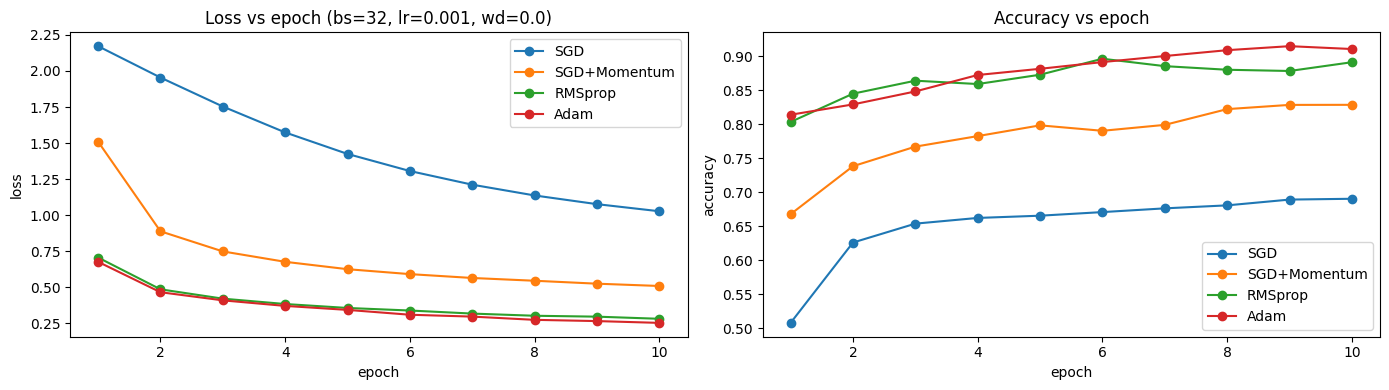

In [30]:
from torch.optim import RMSprop

epochs = 10
batch_size = 32
fixed_lr = 1e-3
fixed_wd = 0.0

optimizer_builders = {
    "SGD": lambda params: SGD(params, lr=fixed_lr, weight_decay=fixed_wd),
    "SGD+Momentum": lambda params: SGD(params, lr=fixed_lr, momentum=0.9, weight_decay=fixed_wd),
    "RMSprop": lambda params: RMSprop(params, lr=fixed_lr, alpha=0.9, weight_decay=fixed_wd),
    "Adam": lambda params: Adam(params, lr=fixed_lr, weight_decay=fixed_wd),
}

trn_dl = get_data(batch_size, transform=None, device=device)

results_opt = {}

for opt_name, make_opt in optimizer_builders.items():
    print(f"training optimizer={opt_name} lr={fixed_lr} bs={batch_size} wd={fixed_wd}")
    model = get_model_1()
    optimizer = make_opt(model.parameters())
    losses, accs = test_model_with_hyper(model, optimizer, epochs=epochs)
    results_opt[opt_name] = (losses, accs)

ep = np.arange(1, epochs + 1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
for opt_name, (losses, accs) in results_opt.items():
    plt.plot(ep, losses, marker="o", label=opt_name)
plt.title(f"Loss vs epoch (bs={batch_size}, lr={fixed_lr}, wd={fixed_wd})")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
for opt_name, (losses, accs) in results_opt.items():
    plt.plot(ep, accs, marker="o", label=opt_name)
plt.title("Accuracy vs epoch")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()